In [114]:
from google.colab import files

uploaded = files.upload()

Saving data_cts_corruption_and_economic_crime.xlsx to data_cts_corruption_and_economic_crime (3).xlsx


CYBERCRIME GLOBAL QUANTITATIVE ANALYSIS

In [115]:

!pip -q install pandas numpy requests openpyxl scipy statsmodels scikit-learn matplotlib

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, jarque_bera
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from IPython.display import display, FileLink

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")





Libraries loaded successfully.


 FILE LOCATION

In [116]:
BASE = Path("/content")

UNODC_FILE = BASE / "data_cts_corruption_and_economic_crime.xlsx"

print("\nUNODC file:")
print(UNODC_FILE)

print("File exists:", UNODC_FILE.exists())

if not UNODC_FILE.exists():
    raise FileNotFoundError(
        "The UNODC Excel file is not in /content."
    )


UNODC file:
/content/data_cts_corruption_and_economic_crime.xlsx
File exists: True


INSPECT WORKBOOK

In [117]:

print("\n" + "="*70)
print("WORKBOOK INSPECTION")
print("="*70)

xls = pd.ExcelFile(UNODC_FILE)

print("Sheets found:")

for i, sheet in enumerate(xls.sheet_names):
    print(i, ":", sheet)



WORKBOOK INSPECTION
Sheets found:
0 : data_cts_corruption_and_economi


LOAD THE UNODC SHEET

In [118]:

SHEET_NAME = xls.sheet_names[0]

print("\nLoading sheet:")
print(SHEET_NAME)

# Read without assuming a header
raw = pd.read_excel(
    UNODC_FILE,
    sheet_name=SHEET_NAME,
    header=None
)

print("\nRaw dimensions:")
print(raw.shape)



Loading sheet:
data_cts_corruption_and_economi

Raw dimensions:
(27082, 13)


FIND THE REAL HEADER ROW

In [119]:


print("\n" + "="*70)
print("SEARCHING FOR HEADER ROW")
print("="*70)

header_row = None

# Search first 30 rows for the row containing
# several expected UNODC fields.

for i in range(min(30, len(raw))):

    row_text = " | ".join(
        raw.iloc[i]
        .astype(str)
        .str.strip()
        .str.lower()
        .tolist()
    )

    score = 0

    for term in [
        "iso3",
        "country",
        "indicator",
        "category",
        "year",
        "value",
        "sex",
        "age"
    ]:

        if term in row_text:
            score += 1

    if score >= 4:
        header_row = i
        break


if header_row is None:

    print("\nCould not automatically identify the header.")

    print("\nFirst 15 rows of the workbook:")
    display(raw.head(15))

    raise ValueError(
        "UNODC header row could not be identified. "
        "The table above shows the actual workbook structure."
    )


print("Header row identified at Excel row:", header_row + 1)


SEARCHING FOR HEADER ROW
Header row identified at Excel row: 3


CREATE DATAFRAME USING HEADER

In [120]:


headers = raw.iloc[header_row].tolist()

df = raw.iloc[header_row + 1:].copy()

df.columns = headers

# Remove duplicate/empty column names
clean_columns = []

for i, col in enumerate(df.columns):

    if pd.isna(col) or str(col).strip() == "":
        clean_columns.append(f"Unnamed_{i}")
    else:
        clean_columns.append(str(col).strip())

df.columns = clean_columns

print("\nDetected columns:")

for col in df.columns:
    print("-", col)


Detected columns:
- Iso3_code
- Country
- Region
- Subregion
- Indicator
- Dimension
- Category
- Sex
- Age
- Year
- Unit of measurement
- VALUE
- Source


STANDARDISE COLUMN NAMES

In [121]:


def normalise_column_name(column):

    text = str(column).strip()

    text = text.lower()

    text = re.sub(
        r"[^a-z0-9]+",
        "_",
        text
    )

    text = text.strip("_")

    return text


original_columns = list(df.columns)

normalised_columns = [
    normalise_column_name(c)
    for c in df.columns
]

df.columns = normalised_columns

print("\nNormalised columns:")

for col in df.columns:
    print("-", col)


def find_column(columns, possible_names):

    for candidate in possible_names:

        candidate_norm = normalise_column_name(candidate)

        for col in columns:

            if col == candidate_norm:
                return col

    # Partial matching
    for candidate in possible_names:

        candidate_norm = normalise_column_name(candidate)

        for col in columns:

            if candidate_norm in col:
                return col

    return None


iso_col = find_column(
    df.columns,
    [
        "Iso3_code",
        "ISO3",
        "ISO3 code",
        "Country ISO3"
    ]
)

country_col = find_column(
    df.columns,
    [
        "Country",
        "Country name"
    ]
)

indicator_col = find_column(
    df.columns,
    [
        "Indicator"
    ]
)

category_col = find_column(
    df.columns,
    [
        "Category"
    ]
)

sex_col = find_column(
    df.columns,
    [
        "Sex"
    ]
)

age_col = find_column(
    df.columns,
    [
        "Age"
    ]
)

year_col = find_column(
    df.columns,
    [
        "Year"
    ]
)

unit_col = find_column(
    df.columns,
    [
        "Unit of measurement",
        "Unit"
    ]
)

value_col = find_column(
    df.columns,
    [
        "VALUE",
        "Value"
    ]
)


print("\n" + "="*70)
print("IDENTIFIED IMPORTANT COLUMNS")
print("="*70)

identified = {
    "ISO3": iso_col,
    "Country": country_col,
    "Indicator": indicator_col,
    "Category": category_col,
    "Sex": sex_col,
    "Age": age_col,
    "Year": year_col,
    "Unit": unit_col,
    "Value": value_col
}

for name, col in identified.items():
    print(f"{name:15} -> {col}")




Normalised columns:
- iso3_code
- country
- region
- subregion
- indicator
- dimension
- category
- sex
- age
- year
- unit_of_measurement
- value
- source

IDENTIFIED IMPORTANT COLUMNS
ISO3            -> iso3_code
Country         -> country
Indicator       -> indicator
Category        -> category
Sex             -> sex
Age             -> age
Year            -> year
Unit            -> unit_of_measurement
Value           -> value


HECK REQUIRED COLUMNS AND RENAME TO STANDARD NAMES

In [122]:
missing_columns = [
    name
    for name, col in identified.items()
    if col is None
]

if missing_columns:

    print("\nMissing columns:", missing_columns)

    raise ValueError(
        "Some required UNODC columns could not be identified."
    )




df = df.rename(
    columns={
        iso_col: "Iso3_code",
        country_col: "Country",
        indicator_col: "Indicator",
        category_col: "Category",
        sex_col: "Sex",
        age_col: "Age",
        year_col: "Year",
        unit_col: "Unit",
        value_col: "VALUE"
    }
)


 CLEAN IMPORTANT VARIABLES

In [123]:
for col in [
    "Iso3_code",
    "Country",
    "Indicator",
    "Category",
    "Sex",
    "Age",
    "Unit"
]:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
    )


# ISO3
df["Iso3_code"] = (
    df["Iso3_code"]
    .str.upper()
    .str.strip()
)


# Year
df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)


# Value
df["VALUE"] = (
    df["VALUE"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["VALUE"] = pd.to_numeric(
    df["VALUE"],
    errors="coerce"
)


# Remove invalid rows
df = df[
    df["Year"].notna()
].copy()

print("\nClean UNODC rows:", len(df))




Clean UNODC rows: 27079


INSPECT CATEGORIES AND EFINE CYBERCRIME CATEGORIES

In [124]:


print("\n" + "="*70)
print("CYBERCRIME CATEGORY INSPECTION")
print("="*70)

categories = (
    df["Category"]
    .dropna()
    .astype(str)
    .value_counts()
)

display(categories.head(30))



cyber_categories = [
    "Fraud: Cyber-related (Cy)",
    "Unlawful access to a computer system",
    "Unlawful interference with a computer system or computer data",
    "Unlawful interception or access of computer data"
]



print("\nChecking exact cybercrime category matches:")

for category in cyber_categories:

    matches = (
        df["Category"]
        .astype(str)
        .str.strip()
        .eq(category)
        .sum()
    )

    print(f"{category}: {matches:,}")


CYBERCRIME CATEGORY INSPECTION


,count
Category,
Theft,4124
Theft: of a motorized vehicle,3854
Burglary,3598
Corruption: Bribery,1652
Corruption,1597
Smuggling of migrants,1579
Fraud,1557
Corruption: Other acts of corruption,1425
Money laundering,1320



Checking exact cybercrime category matches:
Fraud: Cyber-related (Cy): 909
Unlawful access to a computer system: 920
Unlawful interference with a computer system or computer data: 800
Unlawful interception or access of computer data: 594


ILTER CYBERCRIME DATA

In [125]:


cyber = df[
    (
        df["Category"]
        .astype(str)
        .str.strip()
        .isin(cyber_categories)
    )
    &
    (
        df["Year"].between(2015, 2023)
    )
].copy()



print("\n" + "="*70)
print("UNIT OF MEASUREMENT")
print("="*70)

display(
    cyber["Unit"]
    .value_counts()
    .head(20)
)



cyber = cyber[
    cyber["Unit"]
    .astype(str)
    .str.lower()
    .str.contains(
        "rate per 100,000",
        na=False
    )
].copy()




cyber = cyber[
    cyber["Sex"]
    .astype(str)
    .str.lower()
    .eq("total")
].copy()

cyber = cyber[
    cyber["Age"]
    .astype(str)
    .str.lower()
    .eq("total")
].copy()




cyber = cyber[
    cyber["VALUE"].notna()
].copy()

cyber = cyber[
    cyber["VALUE"] >= 0
].copy()


print("\n" + "="*70)
print("FINAL UNODC CYBERCRIME DATA")
print("="*70)

print("Observations:", len(cyber))
print("Countries:", cyber["Iso3_code"].nunique())
print(
    "Years:",
    cyber["Year"].min(),
    "to",
    cyber["Year"].max()
)



UNIT OF MEASUREMENT


,count
Unit,
Counts,1473
"Rate per 100,000 population",1473



FINAL UNODC CYBERCRIME DATA
Observations: 1473
Countries: 95
Years: 2015 to 2023


CREATE LONG DATASET

In [126]:



unodc_long = cyber[
    [
        "Iso3_code",
        "Country",
        "Category",
        "Year",
        "VALUE"
    ]
].copy()

unodc_long = unodc_long.rename(
    columns={
        "VALUE": "crime_rate"
    }
)

unodc_long = unodc_long.sort_values(
    [
        "Country",
        "Year",
        "Category"
    ]
)

display(unodc_long.head(10))


unodc_wide = unodc_long.pivot_table(
    index=[
        "Iso3_code",
        "Country",
        "Year"
    ],
    columns="Category",
    values="crime_rate",
    aggfunc="mean"
).reset_index()

unodc_wide.columns.name = None


# Rename categories
unodc_wide = unodc_wide.rename(
    columns={
        "Fraud: Cyber-related (Cy)": "cyber_fraud_rate",

        "Unlawful access to a computer system":
            "unlawful_access_rate",

        "Unlawful interference with a computer system or computer data":
            "unlawful_interference_rate",

        "Unlawful interception or access of computer data":
            "unlawful_interception_rate"
    }
)


print("\nCountry-year dataset:")
display(unodc_wide.head())


,Iso3_code,Country,Category,Year,crime_rate
23277,ALB,Albania,Fraud: Cyber-related (Cy),2015,1.759451
24373,ALB,Albania,Unlawful access to a computer system,2015,0.172495
25224,ALB,Albania,Unlawful interception or access of computer data,2015,0.000000
24830,ALB,Albania,Unlawful interference with a computer system o...,2015,1.379961
23305,ALB,Albania,Fraud: Cyber-related (Cy),2016,1.759915
24397,ALB,Albania,Unlawful access to a computer system,2016,0.414098
25240,ALB,Albania,Unlawful interception or access of computer data,2016,0.000000
24852,ALB,Albania,Unlawful interference with a computer system o...,2016,2.484587
23346,ALB,Albania,Fraud: Cyber-related (Cy),2017,2.656783
24437,ALB,Albania,Unlawful access to a computer system,2017,0.310533



Country-year dataset:


,Iso3_code,Country,Year,cyber_fraud_rate,unlawful_access_rate,unlawful_interception_rate,unlawful_interference_rate
0,ALB,Albania,2015,1.759451,0.172495,0.0,1.379961
1,ALB,Albania,2016,1.759915,0.414098,0.0,2.484587
2,ALB,Albania,2017,2.656783,0.310533,0.0,2.346249
3,ALB,Albania,2018,2.073090,0.414618,0.0,1.900332
4,ALB,Albania,2019,1.629111,0.485267,0.0,2.426335


DESCRIPTIVE STATISTICS

In [127]:


cyber_descriptives = (
    unodc_long
    .groupby("Category")["crime_rate"]
    .agg(
        observations="count",
        countries="nunique",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .reset_index()
)

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)

display(cyber_descriptives)



DESCRIPTIVE STATISTICS


,Category,observations,countries,mean,median,std,minimum,maximum
0,Fraud: Cyber-related (Cy),373,329,71.108395,11.131498,175.204303,0.0,1696.915341
1,Unlawful access to a computer system,437,392,8.381693,1.607999,19.702748,0.0,290.438515
2,Unlawful interception or access of computer data,283,211,2.079693,0.202086,4.841349,0.0,38.010733
3,Unlawful interference with a computer system o...,380,326,4.235683,0.575930,18.799917,0.0,216.124634


WORLD BANK API FUNCTION

In [128]:


def download_world_bank_indicator(
    indicator_code
):

    url = (
        "https://api.worldbank.org/v2/country/all/"
        f"indicator/{indicator_code}"
        "?format=json&per_page=20000"
    )

    response = requests.get(
        url,
        timeout=60
    )

    response.raise_for_status()

    data = response.json()

    if len(data) < 2:

        raise ValueError(
            f"No World Bank data for {indicator_code}"
        )

    rows = []

    for item in data[1]:

        iso3 = item.get(
            "countryiso3code"
        )

        year = item.get(
            "date"
        )

        value = item.get(
            "value"
        )

        if iso3 and year:

            rows.append({
                "Iso3_code": iso3.upper(),
                "Year": int(year),
                indicator_code: value
            })

    result = pd.DataFrame(rows)

    result[indicator_code] = pd.to_numeric(
        result[indicator_code],
        errors="coerce"
    )

    return result


wb_indicators = {

    "IT.NET.USER.ZS":
        "internet_users_pct",

    "IT.NET.BBND.P2":
        "fixed_broadband_per_100",

    "NY.GDP.PCAP.CD":
        "gdp_per_capita",

    "SL.UEM.TOTL.ZS":
        "unemployment_rate",

    "SI.POV.GINI":
        "gini_index",

    "SE.ADT.LITR.ZS":
        "adult_literacy_rate"
}



print("\n" + "="*70)
print("DOWNLOADING WORLD BANK DATA")
print("="*70)

world_bank = None

for code, name in wb_indicators.items():

    print(
        f"Downloading {code}..."
    )

    temp = download_world_bank_indicator(
        code
    )

    temp = temp.rename(
        columns={
            code: name
        }
    )

    if world_bank is None:

        world_bank = temp

    else:

        world_bank = world_bank.merge(
            temp,
            on=[
                "Iso3_code",
                "Year"
            ],
            how="outer"
        )


world_bank = world_bank[
    world_bank["Year"].between(
        2015,
        2023
    )
].copy()

print(
    "\nWorld Bank rows:",
    len(world_bank)
)

display(world_bank.head())


DOWNLOADING WORLD BANK DATA

World Bank rows: 2340


,Iso3_code,Year,internet_users_pct,fixed_broadband_per_100,gdp_per_capita,unemployment_rate,gini_index,adult_literacy_rate
55,ABW,2015,88.661227,18.236965,27458.220154,NaN,NaN,NaN
56,ABW,2016,93.542454,NaN,27441.550214,NaN,NaN,NaN
57,ABW,2017,97.170000,NaN,28440.041688,NaN,NaN,NaN
58,ABW,2018,NaN,NaN,30082.158423,NaN,NaN,NaN
59,ABW,2019,NaN,17.744406,30654.485124,NaN,NaN,NaN


MERGE UNODC AND WORLD BANK

In [129]:


master = unodc_wide.merge(
    world_bank,
    on=[
        "Iso3_code",
        "Year"
    ],
    how="left"
)

print("\n" + "="*70)
print("MASTER DATASET")
print("="*70)

print("Rows:", len(master))
print(
    "Countries:",
    master["Iso3_code"].nunique()
)

display(master.head())


MASTER DATASET
Rows: 580
Countries: 95


,Iso3_code,Country,Year,cyber_fraud_rate,unlawful_access_rate,unlawful_interception_rate,unlawful_interference_rate,internet_users_pct,fixed_broadband_per_100,gdp_per_capita,unemployment_rate,gini_index,adult_literacy_rate
0,ALB,Albania,2015,1.759451,0.172495,0.0,1.379961,56.900002,8.378780,4199.539129,17.193,32.8,NaN
1,ALB,Albania,2016,1.759915,0.414098,0.0,2.484587,59.599998,9.192244,4457.634122,15.418,33.7,NaN
2,ALB,Albania,2017,2.656783,0.310533,0.0,2.346249,62.400002,10.475730,5006.360130,13.616,33.1,98.809998
3,ALB,Albania,2018,2.073090,0.414618,0.0,1.900332,65.400002,12.505809,5897.654526,12.304,30.1,NaN
4,ALB,Albania,2019,1.629111,0.485267,0.0,2.426335,68.550391,15.119254,6069.439031,11.466,30.1,NaN


MISSING DATA

In [130]:


analysis_variables = [
    "cyber_fraud_rate",
    "unlawful_access_rate",
    "unlawful_interference_rate",
    "unlawful_interception_rate",
    "internet_users_pct",
    "fixed_broadband_per_100",
    "gdp_per_capita",
    "unemployment_rate",
    "gini_index",
    "adult_literacy_rate"
]

missing_summary = pd.DataFrame({

    "variable":
        analysis_variables,

    "missing_count": [
        master[v].isna().sum()
        for v in analysis_variables
    ],

    "missing_percent": [
        master[v].isna().mean() * 100
        for v in analysis_variables
    ]
})

print("\n" + "="*70)
print("MISSING DATA ANALYSIS")
print("="*70)

display(missing_summary)


MISSING DATA ANALYSIS


,variable,missing_count,missing_percent
0,cyber_fraud_rate,207,35.689655
1,unlawful_access_rate,143,24.655172
2,unlawful_interference_rate,200,34.482759
3,unlawful_interception_rate,297,51.206897
4,internet_users_pct,18,3.103448
5,fixed_broadband_per_100,30,5.172414
6,gdp_per_capita,15,2.586207
7,unemployment_rate,56,9.655172
8,gini_index,217,37.413793
9,adult_literacy_rate,465,80.172414


PRINCIPAL ANALYSIS DATASET

In [131]:


predictors = [
    "internet_users_pct",
    "fixed_broadband_per_100",
    "gdp_per_capita",
    "unemployment_rate",
    "gini_index",
    "adult_literacy_rate"
]

analysis_df = master[
    [
        "Iso3_code",
        "Country",
        "Year",
        "cyber_fraud_rate"
    ]
    + predictors
].copy()


PEARSON CORRELATIONS

In [132]:

print("\n" + "="*70)
print("PEARSON CORRELATIONS")
print("="*70)

correlation_results = []

for predictor in predictors:

    temp = analysis_df[
        [
            "cyber_fraud_rate",
            predictor
        ]
    ].dropna()

    if len(temp) >= 3:

        r, p = pearsonr(
            temp["cyber_fraud_rate"],
            temp[predictor]
        )

        correlation_results.append({

            "variable": predictor,

            "n": len(temp),

            "pearson_r": r,

            "p_value": p,

            "significant_at_0.05":
                p < 0.05
        })


correlations = pd.DataFrame(
    correlation_results
)

display(correlations)


PEARSON CORRELATIONS


,variable,n,pearson_r,p_value,significant_at_0.05
0,internet_users_pct,360,0.317924,6.740401e-10,True
1,fixed_broadband_per_100,354,0.310905,2.262615e-09,True
2,gdp_per_capita,363,0.326718,1.779624e-10,True
3,unemployment_rate,327,-0.050474,3.629171e-01,False
4,gini_index,227,-0.108699,1.023595e-01,False
5,adult_literacy_rate,86,0.207163,5.563833e-02,False


2023 CROSS-SECTION

In [133]:


cross_2023 = analysis_df[
    analysis_df["Year"] == 2023
].copy()

print("\n" + "="*70)
print("2023 CROSS-SECTION")
print("="*70)

print(
    "Country records:",
    len(cross_2023)
)


# Complete regression cases
regression_variables = [
    "cyber_fraud_rate"
] + predictors

regression_2023 = cross_2023[
    regression_variables
].dropna().copy()

print(
    "Complete regression cases:",
    len(regression_2023)
)



2023 CROSS-SECTION
Country records: 65
Complete regression cases: 2


TRANSFORM SKEWED VARIABLES

In [134]:

regression_2023[
    "log_cyber_fraud_rate"
] = np.log1p(
    regression_2023[
        "cyber_fraud_rate"
    ]
)

regression_2023[
    "log_gdp_per_capita"
] = np.log1p(
    regression_2023[
        "gdp_per_capita"
    ]
)


MULTIPLE LINEAR REGRESSION

In [135]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

regression_predictors = [
    "internet_users_pct",
    "fixed_broadband_per_100",
    "log_gdp_per_capita",
    "unemployment_rate",
    "gini_index",
    "adult_literacy_rate"
]

# Keep only complete observations
model_data = regression_2023[
    regression_predictors + ["log_cyber_fraud_rate"]
].replace([np.inf, -np.inf], np.nan).dropna()

X = model_data[regression_predictors].copy()
y = model_data["log_cyber_fraud_rate"].copy()

# Add intercept
X = sm.add_constant(X, has_constant="add")

# OLS
ols_model = sm.OLS(y, X).fit()

# HC3 robust covariance
robust_model = ols_model.get_robustcov_results(cov_type="HC3")

print("\n" + "=" * 70)
print("MULTIPLE LINEAR REGRESSION - HC3 ROBUST STANDARD ERRORS")
print("=" * 70)

# Print the main statistics manually instead of robust_model.summary()
print("Number of observations:", int(robust_model.nobs))
print("R-squared:", round(robust_model.rsquared, 4))
print("Adjusted R-squared:", round(robust_model.rsquared_adj, 4))

print("\nCoefficients:")
print(
    pd.DataFrame({
        "Coefficient": robust_model.params,
        "Robust_SE": robust_model.bse,
        "t_value": robust_model.tvalues,
        "p_value": robust_model.pvalues
    }, index=X.columns).round(4)
)

print("\n95% Confidence Intervals:")
print(
    pd.DataFrame(
        robust_model.conf_int(),
        index=X.columns,
        columns=["Lower_95", "Upper_95"]
    ).round(4)
)


MULTIPLE LINEAR REGRESSION - HC3 ROBUST STANDARD ERRORS
Number of observations: 2
R-squared: 1.0
Adjusted R-squared: nan

Coefficients:
                         Coefficient  Robust_SE  t_value  p_value
const                         0.0001        inf      0.0      NaN
internet_users_pct            0.0183        inf      0.0      NaN
fixed_broadband_per_100       0.0105        inf      0.0      NaN
log_gdp_per_capita            0.0016        inf      0.0      NaN
unemployment_rate            -0.0082        inf     -0.0      NaN
gini_index                    0.0557        inf      0.0      NaN
adult_literacy_rate           0.0002        inf      0.0      NaN

95% Confidence Intervals:
                         Lower_95  Upper_95
const                         NaN       NaN
internet_users_pct            NaN       NaN
fixed_broadband_per_100       NaN       NaN
log_gdp_per_capita            NaN       NaN
unemployment_rate             NaN       NaN
gini_index                    NaN       NaN


REGRESSION COEFFICIENT TABLE

In [136]:


names = robust_model.model.exog_names

conf = robust_model.conf_int()

ols_coefficients = pd.DataFrame({

    "variable":
        names,

    "coefficient":
        robust_model.params,

    "robust_std_error":
        robust_model.bse,

    "t_value":
        robust_model.tvalues,

    "p_value":
        robust_model.pvalues,

    "ci_lower":
        conf[:, 0],

    "ci_upper":
        conf[:, 1]
})

display(ols_coefficients)


,variable,coefficient,robust_std_error,t_value,p_value,ci_lower,ci_upper
0,const,0.000116,inf,0.0,NaN,NaN,NaN
1,internet_users_pct,0.018291,inf,0.0,NaN,NaN,NaN
2,fixed_broadband_per_100,0.010534,inf,0.0,NaN,NaN,NaN
3,log_gdp_per_capita,0.001568,inf,0.0,NaN,NaN,NaN
4,unemployment_rate,-0.008196,inf,-0.0,NaN,NaN,NaN
5,gini_index,0.055711,inf,0.0,NaN,NaN,NaN
6,adult_literacy_rate,0.000228,inf,0.0,NaN,NaN,NaN


MODEL STATISTICS

In [137]:


model_statistics = pd.DataFrame({

    "metric": [

        "Observations",

        "R_squared",

        "Adjusted_R_squared",

        "F_statistic",

        "F_p_value",

        "AIC",

        "BIC"
    ],

    "value": [

        int(ols_model.nobs),

        ols_model.rsquared,

        ols_model.rsquared_adj,

        ols_model.fvalue,

        ols_model.f_pvalue,

        ols_model.aic,

        ols_model.bic
    ]
})

print("\nModel statistics:")

display(model_statistics)




Model statistics:


,metric,value
0,Observations,2.000000
1,R_squared,1.000000
2,Adjusted_R_squared,NaN
3,F_statistic,NaN
4,F_p_value,NaN
5,AIC,-128.953682
6,BIC,-131.567388


VIF

In [138]:


print("\n" + "="*70)
print("MULTICOLLINEARITY - VIF")
print("="*70)

vif_data = regression_2023[
    regression_predictors
].dropna()

vif_table = pd.DataFrame({

    "variable":
        vif_data.columns,

    "VIF": [

        variance_inflation_factor(
            vif_data.values,
            i
        )

        for i
        in range(
            vif_data.shape[1]
        )
    ]
})

display(vif_table)



MULTICOLLINEARITY - VIF


,variable,VIF
0,internet_users_pct,1.000800e+15
1,fixed_broadband_per_100,1.000800e+15
2,log_gdp_per_capita,1.000800e+15
3,unemployment_rate,1.000800e+15
4,gini_index,1.000800e+15
5,adult_literacy_rate,1.000800e+15


RESIDUAL DIAGNOSTICS

In [139]:


residuals = ols_model.resid

fitted = ols_model.fittedvalues


# Jarque-Bera
jb_stat, jb_p = jarque_bera(
    residuals
)


# Breusch-Pagan
bp = het_breuschpagan(
    residuals,
    ols_model.model.exog
)


diagnostics = pd.DataFrame({

    "test": [

        "Jarque-Bera",

        "Breusch-Pagan LM",

        "Breusch-Pagan F"
    ],

    "statistic": [

        jb_stat,

        bp[0],

        bp[2]
    ],

    "p_value": [

        jb_p,

        bp[1],

        bp[3]
    ]
})

print("\n" + "="*70)
print("REGRESSION DIAGNOSTICS")
print("="*70)

display(diagnostics)



REGRESSION DIAGNOSTICS


,test,statistic,p_value
0,Jarque-Bera,0.333333,0.846482
1,Breusch-Pagan LM,-inf,1.000000
2,Breusch-Pagan F,NaN,NaN


RESIDUAL PLOT

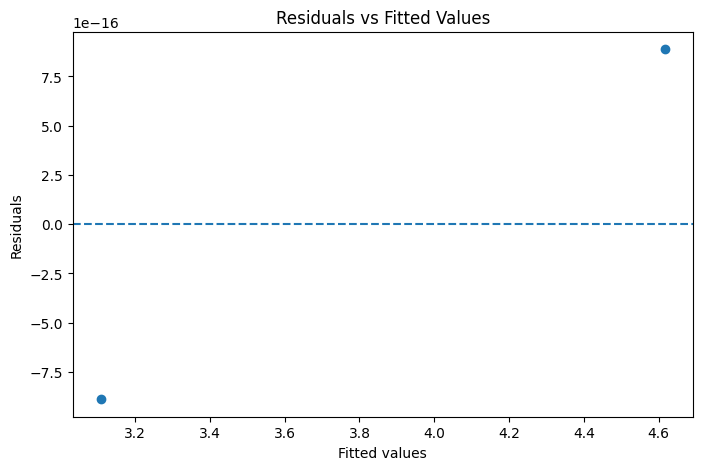

In [140]:


plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    fitted,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fitted values"
)

plt.ylabel(
    "Residuals"
)

plt.title(
    "Residuals vs Fitted Values"
)

plt.show()

Q-Q PLOT

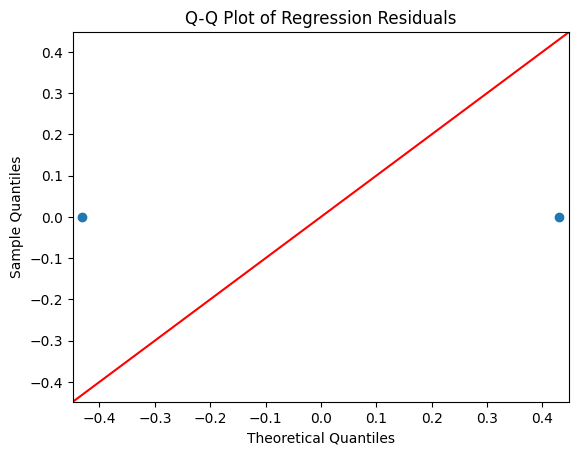

In [141]:

sm.qqplot(
    residuals,
    line="45"
)

plt.title(
    "Q-Q Plot of Regression Residuals"
)

plt.show()

-MEANS CLUSTER ANALYSIS

In [142]:


print("\n" + "="*70)
print("K-MEANS CLUSTER ANALYSIS")
print("="*70)

# Variables used for clustering
cluster_variables = [
    "cyber_fraud_rate",
    "internet_users_pct",
    "fixed_broadband_per_100",
    "log_gdp_per_capita",
    "unemployment_rate",
    "gini_index",
    "adult_literacy_rate"
]



K-MEANS CLUSTER ANALYSIS


In [143]:


cross_2023 = cross_2023.copy()


cross_2023["log_gdp_per_capita"] = np.log1p(
    cross_2023["gdp_per_capita"]
)



cluster_df = cross_2023[
    [
        "Iso3_code",
        "Country"
    ] + cluster_variables
].dropna().copy()

print(
    "Countries available for clustering:",
    len(cluster_df)
)



if len(cluster_df) < 4:

    print(
        "\nNot enough complete country observations "
        "for meaningful K-Means clustering."
    )

    cluster_df["cluster"] = np.nan

    cluster_evaluation = pd.DataFrame()

    cluster_profile = pd.DataFrame()

else:



    scaler = StandardScaler()

    X_cluster = scaler.fit_transform(
        cluster_df[cluster_variables]
    )



    cluster_scores = []

    max_k = min(
        6,
        len(cluster_df) - 1
    )

    for k in range(2, max_k + 1):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(
            X_cluster
        )

        score = silhouette_score(
            X_cluster,
            labels
        )

        cluster_scores.append(
            {
                "k": k,
                "silhouette_score": score
            }
        )



    cluster_evaluation = pd.DataFrame(
        cluster_scores
    )

    print("\nSilhouette scores:")

    display(
        cluster_evaluation
    )



    best_k = int(
        cluster_evaluation.loc[
            cluster_evaluation[
                "silhouette_score"
            ].idxmax(),
            "k"
        ]
    )

    print(
        "\nBest number of clusters:",
        best_k
    )

Countries available for clustering: 2

Not enough complete country observations for meaningful K-Means clustering.


Final K-Means model

In [144]:
if len(cluster_df) < 4:
    print("Clustering was not performed because there are not enough complete country observations.")
else:
    kmeans = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=20
    )

    cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

    display(
        cluster_df[
            ["Iso3_code", "Country"] + cluster_variables + ["cluster"]
        ].sort_values("cluster")
    )

    cluster_counts = (
        cluster_df["cluster"]
        .value_counts()
        .sort_index()
        .rename("country_count")
        .reset_index()
    )

    cluster_counts.columns = ["cluster", "country_count"]

    display(cluster_counts)

Clustering was not performed because there are not enough complete country observations.


Cluster profiles

In [145]:


    cluster_profile = (
        cluster_df
        .groupby("cluster")[
            cluster_variables
        ]
        .mean()
        .reset_index()
    )

    cluster_counts = (
        cluster_df
        .groupby("cluster")
        .size()
        .reset_index(
            name="country_count"
        )
    )

    cluster_profile = cluster_profile.merge(
        cluster_counts,
        on="cluster"
    )

    print("\nCluster profiles:")

    display(
        cluster_profile
    )


Cluster profiles:


,cluster,cyber_fraud_rate,internet_users_pct,fixed_broadband_per_100,log_gdp_per_capita,unemployment_rate,gini_index,adult_literacy_rate,country_count


Countries in each cluster

In [146]:


    print("\nCountries by cluster:")

    for cluster_number in sorted(
        cluster_df["cluster"].unique()
    ):

        countries = cluster_df.loc[
            cluster_df["cluster"] == cluster_number,
            "Country"
        ].tolist()

        print(
            f"\nCluster {cluster_number}: "
            f"{len(countries)} countries"
        )

        print(
            ", ".join(countries[:30])
        )

        if len(countries) > 30:
            print(
                f"... and {len(countries) - 30} more"
            )

print("\nK-Means clustering completed.")


Countries by cluster:

Cluster nan: 0 countries


K-Means clustering completed.


IDENTIFY THE MASTER DATASET

In [147]:
print("\nChecking available datasets...")

if "master" in globals():
    master_df = master.copy()
    print("Using dataset: master")

elif "master_data" in globals():
    master_df = master_data.copy()
    print("Using dataset: master_data")

elif "merged_data" in globals():
    master_df = merged_data.copy()
    print("Using dataset: merged_data")

else:
    raise NameError(
        "Could not find the merged master dataset. "
        "Please rerun the MASTER DATASET section."
    )

print("Master dataset loaded successfully.")
print("Rows:", len(master_df))
print("Countries:", master_df["Iso3_code"].nunique())
print(
    "Years:",
    master_df["Year"].min(),
    "to",
    master_df["Year"].max()
)

print("\nColumns:")
print(master_df.columns.tolist())


Checking available datasets...
Using dataset: master
Master dataset loaded successfully.
Rows: 580
Countries: 95
Years: 2015 to 2023

Columns:
['Iso3_code', 'Country', 'Year', 'cyber_fraud_rate', 'unlawful_access_rate', 'unlawful_interception_rate', 'unlawful_interference_rate', 'internet_users_pct', 'fixed_broadband_per_100', 'gdp_per_capita', 'unemployment_rate', 'gini_index', 'adult_literacy_rate']


CORRECTED REGRESSION ANALYSIS

In [148]:

print("\n" + "="*70)
print("CORRECTED REGRESSION ANALYSIS")
print("="*70)

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import jarque_bera


CORRECTED REGRESSION ANALYSIS


MAIN MODEL VARIABLES

In [149]:


main_predictors = [
    "internet_users_pct",
    "fixed_broadband_per_100",
    "gdp_per_capita",
    "unemployment_rate"
]

outcome = "cyber_fraud_rate"

# Work from the master dataset
regression_data = master_df[
    ["Iso3_code", "Country", "Year", outcome] + main_predictors
].copy()

# Remove rows missing variables required by main model
regression_data = regression_data.dropna().copy()

# Log-transform skewed variables
regression_data["log_cyber_fraud_rate"] = np.log1p(
    regression_data[outcome]
)

regression_data["log_gdp_per_capita"] = np.log1p(
    regression_data["gdp_per_capita"]
)

print("\nComplete observations:", len(regression_data))
print("Countries:", regression_data["Iso3_code"].nunique())
print(
    "Years:",
    regression_data["Year"].min(),
    "to",
    regression_data["Year"].max()
)


Complete observations: 324
Countries: 58
Years: 2015 to 2023


MODEL 1: LEVEL CYBERCRIME RATE

In [150]:

X1 = regression_data[
    [
        "internet_users_pct",
        "fixed_broadband_per_100",
        "log_gdp_per_capita",
        "unemployment_rate"
    ]
]

X1 = sm.add_constant(X1)

y1 = regression_data["log_cyber_fraud_rate"]

model1 = sm.OLS(y1, X1).fit(cov_type="HC3")

print("\n")
print("="*70)
print("MODEL 1: POOLED OLS")
print("="*70)

print(model1.summary())




MODEL 1: POOLED OLS
                             OLS Regression Results                             
Dep. Variable:     log_cyber_fraud_rate   R-squared:                       0.343
Model:                              OLS   Adj. R-squared:                  0.335
Method:                   Least Squares   F-statistic:                     40.89
Date:                  Wed, 16 Sep 2026   Prob (F-statistic):           1.18e-27
Time:                          20:27:59   Log-Likelihood:                -603.68
No. Observations:                   324   AIC:                             1217.
Df Residuals:                       319   BIC:                             1236.
Df Model:                             4                                         
Covariance Type:                    HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

COEFFICIENT TABLE

In [151]:


coefficients = pd.DataFrame({
    "variable": model1.params.index,
    "coefficient": model1.params.values,
    "robust_std_error": model1.bse.values,
    "t_value": model1.tvalues.values,
    "p_value": model1.pvalues.values,
    "ci_lower": model1.conf_int()[0].values,
    "ci_upper": model1.conf_int()[1].values
})

print("\nCoefficient table:")
display(coefficients)


Coefficient table:


,variable,coefficient,robust_std_error,t_value,p_value,ci_lower,ci_upper
0,const,-8.116297,1.448124,-5.604696,2.086205e-08,-10.954569,-5.278026
1,internet_users_pct,0.017125,0.009061,1.889936,5.876652e-02,-0.000635,0.034885
2,fixed_broadband_per_100,-0.004333,0.013473,-0.321630,7.477327e-01,-0.030740,0.022073
3,log_gdp_per_capita,1.019802,0.185752,5.490117,4.016674e-08,0.655734,1.383870
4,unemployment_rate,-0.029426,0.017715,-1.661007,9.671209e-02,-0.064147,0.005296


MODEL STATISTICS

In [152]:


model_statistics = pd.DataFrame({
    "metric": [
        "Observations",
        "R_squared",
        "Adjusted_R_squared",
        "F_statistic",
        "F_p_value",
        "AIC",
        "BIC"
    ],
    "value": [
        model1.nobs,
        model1.rsquared,
        model1.rsquared_adj,
        model1.fvalue,
        model1.f_pvalue,
        model1.aic,
        model1.bic
    ]
})

print("\nModel statistics:")
display(model_statistics)


Model statistics:


,metric,value
0,Observations,3.240000e+02
1,R_squared,3.430970e-01
2,Adjusted_R_squared,3.348600e-01
3,F_statistic,4.088706e+01
4,F_p_value,1.176766e-27
5,AIC,1.217365e+03
6,BIC,1.236268e+03


MULTICOLLINEARITY - VIF

In [153]:


print("\n" + "="*70)
print("MULTICOLLINEARITY - VIF")
print("="*70)

vif_data = regression_data[
    [
        "internet_users_pct",
        "fixed_broadband_per_100",
        "log_gdp_per_capita",
        "unemployment_rate"
    ]
].copy()

vif_matrix = pd.DataFrame()

vif_matrix["variable"] = vif_data.columns

vif_matrix["VIF"] = [
    variance_inflation_factor(
        vif_data.values,
        i
    )
    for i in range(vif_data.shape[1])
]

display(vif_matrix)

print("\nVIF interpretation:")
for _, row in vif_matrix.iterrows():

    variable = row["variable"]
    vif = row["VIF"]

    if vif < 5:
        interpretation = "Low / acceptable multicollinearity"
    elif vif < 10:
        interpretation = "Moderate multicollinearity"
    else:
        interpretation = "High multicollinearity"

    print(
        f"{variable}: VIF = {vif:.2f} → {interpretation}"
    )


MULTICOLLINEARITY - VIF


,variable,VIF
0,internet_users_pct,2.012218
1,fixed_broadband_per_100,2.619544
2,log_gdp_per_capita,3.274262
3,unemployment_rate,1.162793



VIF interpretation:
internet_users_pct: VIF = 2.01 → Low / acceptable multicollinearity
fixed_broadband_per_100: VIF = 2.62 → Low / acceptable multicollinearity
log_gdp_per_capita: VIF = 3.27 → Low / acceptable multicollinearity
unemployment_rate: VIF = 1.16 → Low / acceptable multicollinearity


REGRESSION DIAGNOSTICS

In [154]:


print("\n" + "="*70)
print("REGRESSION DIAGNOSTICS")
print("="*70)

residuals = model1.resid
fitted = model1.fittedvalues

# Jarque-Bera normality test
jb_result = jarque_bera(residuals)

# Breusch-Pagan heteroscedasticity test
bp_result = het_breuschpagan(
    residuals,
    model1.model.exog
)

diagnostics = pd.DataFrame({
    "test": [
        "Jarque-Bera",
        "Breusch-Pagan LM",
        "Breusch-Pagan F"
    ],
    "statistic": [
        jb_result.statistic,
        bp_result[0],
        bp_result[2]
    ],
    "p_value": [
        jb_result.pvalue,
        bp_result[1],
        bp_result[3]
    ]
})

display(diagnostics)

print("\nDiagnostic interpretation:")

for _, row in diagnostics.iterrows():

    if row["p_value"] >= 0.05:
        interpretation = (
            "No statistically significant evidence "
            "against the null assumption"
        )
    else:
        interpretation = (
            "Statistically significant evidence "
            "against the null assumption"
        )

    print(
        f"{row['test']}: p = {row['p_value']:.4f} → "
        f"{interpretation}"
    )


REGRESSION DIAGNOSTICS


,test,statistic,p_value
0,Jarque-Bera,4.154186,0.125294
1,Breusch-Pagan LM,8.554249,0.073260
2,Breusch-Pagan F,2.162658,0.073028



Diagnostic interpretation:
Jarque-Bera: p = 0.1253 → No statistically significant evidence against the null assumption
Breusch-Pagan LM: p = 0.0733 → No statistically significant evidence against the null assumption
Breusch-Pagan F: p = 0.0730 → No statistically significant evidence against the null assumption


RESIDUAL DIAGNOSTIC PLOTS

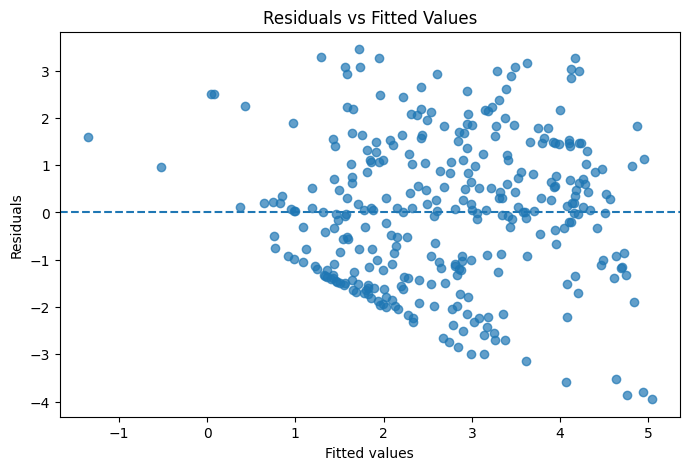

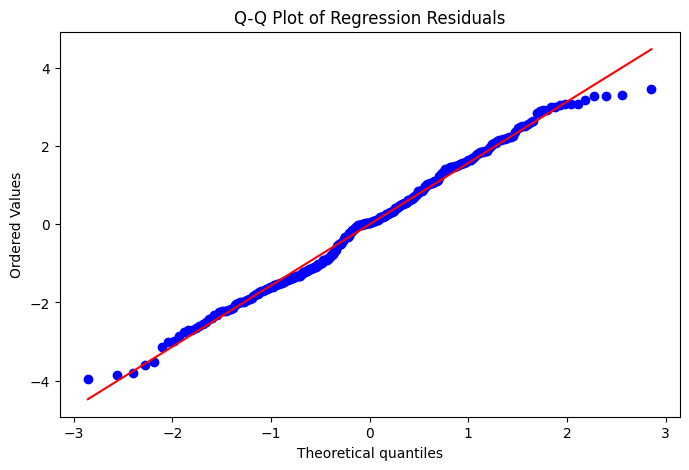

In [155]:


import matplotlib.pyplot as plt
import scipy.stats as stats

# Residuals vs fitted
plt.figure(figsize=(8, 5))

plt.scatter(
    fitted,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()


# Q-Q plot
plt.figure(figsize=(8, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Regression Residuals")

plt.show()

SUPPLEMENTARY SOCIOECONOMIC REGRESSION

In [156]:


print("\n" + "="*70)
print("SUPPLEMENTARY SOCIOECONOMIC REGRESSION")
print("="*70)


supp_data = master_df[
    [
        "Iso3_code",
        "Country",
        "Year",
        "cyber_fraud_rate",
        "internet_users_pct",
        "fixed_broadband_per_100",
        "gdp_per_capita",
        "unemployment_rate",
        "gini_index"
    ]
].copy()



supp_data["log_cyber_fraud_rate"] = np.log1p(
    supp_data["cyber_fraud_rate"]
)

supp_data["log_gdp_per_capita"] = np.log1p(
    supp_data["gdp_per_capita"]
)



supp_data = supp_data.dropna().copy()

print(
    "\nComplete observations:",
    len(supp_data)
)

print(
    "Countries:",
    supp_data["Iso3_code"].nunique()
)

print(
    "Years:",
    supp_data["Year"].min(),
    "to",
    supp_data["Year"].max()
)


supplementary_predictors = [
    "internet_users_pct",
    "fixed_broadband_per_100",
    "log_gdp_per_capita",
    "unemployment_rate",
    "gini_index"
]

if len(supp_data) > len(supplementary_predictors) + 2:

    X_supp = supp_data[
        supplementary_predictors
    ]

    X_supp = sm.add_constant(X_supp)

    y_supp = supp_data[
        "log_cyber_fraud_rate"
    ]

    supplementary_model = sm.OLS(
        y_supp,
        X_supp
    ).fit(
        cov_type="HC3"
    )

    print("\n")
    print("="*70)
    print("GINI SUPPLEMENTARY MODEL")
    print("="*70)

    print(
        supplementary_model.summary()
    )

    supplementary_coefficients = pd.DataFrame({
        "variable":
            supplementary_model.params.index,
        "coefficient":
            supplementary_model.params.values,
        "robust_std_error":
            supplementary_model.bse.values,
        "t_value":
            supplementary_model.tvalues.values,
        "p_value":
            supplementary_model.pvalues.values,
        "ci_lower":
            supplementary_model.conf_int()[0].values,
        "ci_upper":
            supplementary_model.conf_int()[1].values
    })

    print("\nCoefficient table:")
    display(
        supplementary_coefficients
    )

else:

    supplementary_model = None
    supplementary_coefficients = pd.DataFrame()

    print(
        "\nNot enough complete observations "
        "for a reliable Gini regression."
    )





SUPPLEMENTARY SOCIOECONOMIC REGRESSION

Complete observations: 225
Countries: 42
Years: 2015 to 2023


GINI SUPPLEMENTARY MODEL
                             OLS Regression Results                             
Dep. Variable:     log_cyber_fraud_rate   R-squared:                       0.343
Model:                              OLS   Adj. R-squared:                  0.328
Method:                   Least Squares   F-statistic:                     21.49
Date:                  Wed, 16 Sep 2026   Prob (F-statistic):           1.77e-17
Time:                          20:28:00   Log-Likelihood:                -409.98
No. Observations:                   225   AIC:                             832.0
Df Residuals:                       219   BIC:                             852.4
Df Model:                             5                                         
Covariance Type:                    HC3                                         
                              coef    std err          z     

,variable,coefficient,robust_std_error,t_value,p_value,ci_lower,ci_upper
0,const,-12.221387,2.677563,-4.564369,5.009988e-06,-17.469314,-6.973459
1,internet_users_pct,0.026806,0.011718,2.287665,2.215704e-02,0.003840,0.049772
2,fixed_broadband_per_100,0.002605,0.022263,0.117010,9.068525e-01,-0.041030,0.046240
3,log_gdp_per_capita,1.093342,0.336769,3.246567,1.168059e-03,0.433288,1.753397
4,unemployment_rate,-0.008160,0.019940,-0.409251,6.823553e-01,-0.047241,0.030921
5,gini_index,0.075231,0.015196,4.950651,7.396560e-07,0.045447,0.105014


SUPPLEMENTARY SOCIOECONOMIC REGRESSION

In [157]:
print("\n" + "="*70)
print("SUPPLEMENTARY SOCIOECONOMIC REGRESSION")
print("="*70)



supp_data = master_df[
    [
        "Iso3_code",
        "Country",
        "Year",
        "cyber_fraud_rate",
        "internet_users_pct",
        "fixed_broadband_per_100",
        "gdp_per_capita",
        "unemployment_rate",
        "gini_index"
    ]
].copy()


supp_data["log_cyber_fraud_rate"] = np.log1p(
    supp_data["cyber_fraud_rate"]
)

supp_data["log_gdp_per_capita"] = np.log1p(
    supp_data["gdp_per_capita"]
)



supp_data = supp_data.dropna().copy()

print(
    "\nComplete observations:",
    len(supp_data)
)

print(
    "Countries:",
    supp_data["Iso3_code"].nunique()
)

print(
    "Years:",
    supp_data["Year"].min(),
    "to",
    supp_data["Year"].max()
)



supplementary_predictors = [
    "internet_users_pct",
    "fixed_broadband_per_100",
    "log_gdp_per_capita",
    "unemployment_rate",
    "gini_index"
]

if len(supp_data) > len(supplementary_predictors) + 2:

    X_supp = supp_data[
        supplementary_predictors
    ]

    X_supp = sm.add_constant(X_supp)

    y_supp = supp_data[
        "log_cyber_fraud_rate"
    ]

    supplementary_model = sm.OLS(
        y_supp,
        X_supp
    ).fit(
        cov_type="HC3"
    )

    print("\n")
    print("="*70)
    print("GINI SUPPLEMENTARY MODEL")
    print("="*70)

    print(
        supplementary_model.summary()
    )

    supplementary_coefficients = pd.DataFrame({
        "variable":
            supplementary_model.params.index,
        "coefficient":
            supplementary_model.params.values,
        "robust_std_error":
            supplementary_model.bse.values,
        "t_value":
            supplementary_model.tvalues.values,
        "p_value":
            supplementary_model.pvalues.values,
        "ci_lower":
            supplementary_model.conf_int()[0].values,
        "ci_upper":
            supplementary_model.conf_int()[1].values
    })

    print("\nCoefficient table:")
    display(
        supplementary_coefficients
    )

else:

    supplementary_model = None
    supplementary_coefficients = pd.DataFrame()

    print(
        "\nNot enough complete observations "
        "for a reliable Gini regression."
    )




SUPPLEMENTARY SOCIOECONOMIC REGRESSION

Complete observations: 225
Countries: 42
Years: 2015 to 2023


GINI SUPPLEMENTARY MODEL
                             OLS Regression Results                             
Dep. Variable:     log_cyber_fraud_rate   R-squared:                       0.343
Model:                              OLS   Adj. R-squared:                  0.328
Method:                   Least Squares   F-statistic:                     21.49
Date:                  Wed, 16 Sep 2026   Prob (F-statistic):           1.77e-17
Time:                          20:28:00   Log-Likelihood:                -409.98
No. Observations:                   225   AIC:                             832.0
Df Residuals:                       219   BIC:                             852.4
Df Model:                             5                                         
Covariance Type:                    HC3                                         
                              coef    std err          z     

,variable,coefficient,robust_std_error,t_value,p_value,ci_lower,ci_upper
0,const,-12.221387,2.677563,-4.564369,5.009988e-06,-17.469314,-6.973459
1,internet_users_pct,0.026806,0.011718,2.287665,2.215704e-02,0.003840,0.049772
2,fixed_broadband_per_100,0.002605,0.022263,0.117010,9.068525e-01,-0.041030,0.046240
3,log_gdp_per_capita,1.093342,0.336769,3.246567,1.168059e-03,0.433288,1.753397
4,unemployment_rate,-0.008160,0.019940,-0.409251,6.823553e-01,-0.047241,0.030921
5,gini_index,0.075231,0.015196,4.950651,7.396560e-07,0.045447,0.105014


CORRECTED K-MEANS CLUSTERING

In [158]:

print("\n" + "="*70)
print("CORRECTED K-MEANS CLUSTERING")
print("="*70)

cluster_variables = [
    "cyber_fraud_rate",
    "internet_users_pct",
    "fixed_broadband_per_100",
    "gdp_per_capita",
    "unemployment_rate"
]

cluster_df = master_df[
    [
        "Iso3_code",
        "Country",
        "Year"
    ] + cluster_variables
].copy()

# Use 2023 where available
cluster_2023 = cluster_df[
    cluster_df["Year"] == 2023
].copy()

cluster_2023 = cluster_2023.dropna().copy()

# Log-transform GDP
cluster_2023["log_gdp_per_capita"] = np.log1p(
    cluster_2023["gdp_per_capita"]
)

cluster_variables_final = [
    "cyber_fraud_rate",
    "internet_users_pct",
    "fixed_broadband_per_100",
    "log_gdp_per_capita",
    "unemployment_rate"
]

cluster_2023 = cluster_2023[
    [
        "Iso3_code",
        "Country"
    ] + cluster_variables_final
].dropna()

print(
    "Complete countries available:",
    len(cluster_2023)
)

if len(cluster_2023) >= 6:

    scaler = StandardScaler()

    X_cluster = scaler.fit_transform(
        cluster_2023[
            cluster_variables_final
        ]
    )

    # Test k = 2 to 6
    cluster_scores = []

    max_k = min(
        6,
        len(cluster_2023) - 1
    )

    for k in range(2, max_k + 1):

        km = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = km.fit_predict(
            X_cluster
        )

        score = silhouette_score(
            X_cluster,
            labels
        )

        cluster_scores.append({
            "k": k,
            "silhouette_score": score
        })

    cluster_evaluation = pd.DataFrame(
        cluster_scores
    )

    print("\nSilhouette scores:")
    display(cluster_evaluation)

    best_k = int(
        cluster_evaluation.loc[
            cluster_evaluation[
                "silhouette_score"
            ].idxmax(),
            "k"
        ]
    )

    print(
        "\nSelected number of clusters:",
        best_k
    )

    final_kmeans = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=20
    )

    cluster_2023["cluster"] = (
        final_kmeans.fit_predict(
            X_cluster
        )
    )

    cluster_profile = (
        cluster_2023
        .groupby("cluster")[
            cluster_variables_final
        ]
        .mean()
        .reset_index()
    )

    cluster_counts = (
        cluster_2023
        .groupby("cluster")
        .size()
        .reset_index(
            name="country_count"
        )
    )

    cluster_profile = cluster_profile.merge(
        cluster_counts,
        on="cluster"
    )

    print("\nCluster profiles:")
    display(cluster_profile)

    print("\nCountries by cluster:")

    for cluster_number in sorted(
        cluster_2023["cluster"].unique()
    ):

        countries = cluster_2023.loc[
            cluster_2023["cluster"] == cluster_number,
            "Country"
        ].tolist()

        print(
            f"\nCluster {cluster_number} "
            f"({len(countries)} countries):"
        )

        print(
            ", ".join(countries)
        )

else:

    cluster_evaluation = pd.DataFrame()
    cluster_profile = pd.DataFrame()

    print(
        "\nStill insufficient complete observations "
        "for K-means."
    )




CORRECTED K-MEANS CLUSTERING
Complete countries available: 34

Silhouette scores:


,k,silhouette_score
0,2,0.311596
1,3,0.313797
2,4,0.297594
3,5,0.252706
4,6,0.268680



Selected number of clusters: 3

Cluster profiles:


,cluster,cyber_fraud_rate,internet_users_pct,fixed_broadband_per_100,log_gdp_per_capita,unemployment_rate,country_count
0,0,854.563979,94.865418,32.324591,10.892841,7.811500,2
1,1,45.812269,83.068792,22.328499,9.174028,7.119059,17
2,2,151.596598,90.179669,36.253995,10.610331,5.183000,15



Countries by cluster:

Cluster 0 (2 countries):
Spain, Singapore

Cluster 1 (17 countries):
Albania, Armenia, Azerbaijan, Bulgaria, Bosnia and Herzegovina, Brazil, Costa Rica, Ecuador, Croatia, Republic of Moldova, Mexico, North Macedonia, Mongolia, Malaysia, Paraguay, Thailand, Saint Vincent and the Grenadines

Cluster 2 (15 countries):
Austria, Canada, Czechia, Germany, Finland, France, Greece, Iceland, Italy, Lithuania, China, Macao Special Administrative Region, Malta, Poland, Slovakia, Slovenia


DISSERTATION RESULTS SUMMARY

In [159]:

print("\n" + "="*70)
print("DISSERTATION RESULTS SUMMARY")
print("="*70)

results_summary = coefficients.copy()

results_summary["significance"] = results_summary[
    "p_value"
].apply(
    lambda p:
        "***" if p < 0.001
        else "**" if p < 0.01
        else "*" if p < 0.05
        else "ns"
)

display(results_summary)

print("\nMain model:")
print(
    f"Observations = {int(model1.nobs)}"
)

print(
    f"R² = {model1.rsquared:.4f}"
)

print(
    f"Adjusted R² = {model1.rsquared_adj:.4f}"
)

print(
    f"F-statistic = {model1.fvalue:.4f}"
)

print(
    f"F-test p-value = {model1.f_pvalue:.4f}"
)

print(
    "\nSignificance codes:"
)

print(
    "*** p < 0.001"
)

print(
    "** p < 0.01"
)

print(
    "* p < 0.05"
)

print(
    "ns = not statistically significant"
)



DISSERTATION RESULTS SUMMARY


,variable,coefficient,robust_std_error,t_value,p_value,ci_lower,ci_upper,significance
0,const,-8.116297,1.448124,-5.604696,2.086205e-08,-10.954569,-5.278026,***
1,internet_users_pct,0.017125,0.009061,1.889936,5.876652e-02,-0.000635,0.034885,ns
2,fixed_broadband_per_100,-0.004333,0.013473,-0.321630,7.477327e-01,-0.030740,0.022073,ns
3,log_gdp_per_capita,1.019802,0.185752,5.490117,4.016674e-08,0.655734,1.383870,***
4,unemployment_rate,-0.029426,0.017715,-1.661007,9.671209e-02,-0.064147,0.005296,ns



Main model:
Observations = 324
R² = 0.3431
Adjusted R² = 0.3349
F-statistic = 40.8871
F-test p-value = 0.0000

Significance codes:
*** p < 0.001
** p < 0.01
* p < 0.05
ns = not statistically significant


FINAL EXPORT — ERROR-SAFE VERSION

In [160]:
print("\n" + "="*70)
print("EXPORTING FINAL RESULTS")
print("="*70)

output_file = "/content/cybercrime_final_analysis.xlsx"


if "supplementary_model" not in globals():
    supplementary_model = None

if "supplementary_coefficients" not in globals():
    supplementary_coefficients = pd.DataFrame()

if "literacy_model" not in globals():
    literacy_model = None

if "literacy_coefficients" not in globals():
    literacy_coefficients = pd.DataFrame()

if "cluster_evaluation" not in globals():
    cluster_evaluation = pd.DataFrame()

if "cluster_profile" not in globals():
    cluster_profile = pd.DataFrame()

if "cluster_2023" not in globals():
    cluster_2023 = pd.DataFrame()




EXPORTING FINAL RESULTS


CREATE EXCEL WORKBOOK

In [161]:

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # MAIN DATA
    master_df.to_excel(
        writer,
        sheet_name="Master_Data",
        index=False
    )

    # REGRESSION DATA
    regression_data.to_excel(
        writer,
        sheet_name="Regression_Data",
        index=False
    )

    # MAIN REGRESSION
    coefficients.to_excel(
        writer,
        sheet_name="Regression_Coefficients",
        index=False
    )

    model_statistics.to_excel(
        writer,
        sheet_name="Model_Statistics",
        index=False
    )

    # VIF
    vif_matrix.to_excel(
        writer,
        sheet_name="VIF",
        index=False
    )

    # DIAGNOSTICS
    diagnostics.to_excel(
        writer,
        sheet_name="Diagnostics",
        index=False
    )

    # GINI MODEL
    if (
        supplementary_model is not None
        and not supplementary_coefficients.empty
    ):

        supplementary_coefficients.to_excel(
            writer,
            sheet_name="Gini_Model",
            index=False
        )

    # LITERACY MODEL
    if (
        literacy_model is not None
        and not literacy_coefficients.empty
    ):

        literacy_coefficients.to_excel(
            writer,
            sheet_name="Literacy_Model",
            index=False
        )

    # CLUSTER EVALUATION
    if not cluster_evaluation.empty:

        cluster_evaluation.to_excel(
            writer,
            sheet_name="Cluster_Evaluation",
            index=False
        )

    # CLUSTER PROFILE
    if not cluster_profile.empty:

        cluster_profile.to_excel(
            writer,
            sheet_name="Cluster_Profile",
            index=False
        )

    # CLUSTERS
    if not cluster_2023.empty:

        cluster_2023.to_excel(
            writer,
            sheet_name="Clusters",
            index=False
        )

print("\n" + "="*70)
print("EXPORT COMPLETED SUCCESSFULLY")
print("="*70)

print(
    f"\nExcel file created:\n{output_file}"
)


EXPORT COMPLETED SUCCESSFULLY

Excel file created:
/content/cybercrime_final_analysis.xlsx


DOWNLOAD FROM COLAB

In [162]:

from google.colab import files

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>